In [ ]:
!conda create -y -n dataset-1 python=3.10
!conda activate dataset-1

In [ ]:
# ! pip install datasets==3.6.0

In [ ]:
!git clone https://github.com/huggingface/lerobot.git
# !git clone https://huggingface.co/lerobot/smolvla_base
 # pip install -e "./lerobot/.[smolvla]" && \

In [ ]:
!pip install -e "./lerobot/."


In [ ]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset

### o

In [45]:
dataset_name = "yadan0418/record-test"
# Fix the path - use ./ for current directory instead of root /
!hf download {dataset_name} --repo-type dataset --local-dir "./{dataset_name.replace('/', '_')}"

# Load dataset without downloading videos to avoid FFmpeg issues
dataset = LeRobotDataset(
    dataset_name, 
    root=f"./{dataset_name.replace('/', '_')}", 
    download_videos=False,  # Skip video download
    video_backend="pyav"    # Use alternative video backend
)

Fetching 153 files: 100%|███████████████████| 153/153 [00:00<00:00, 2742.38it/s]
/Users/ludvigeriksonbrangstrup/Qualia/hyperstack_smolvla/yadan0418_record-test


In [ ]:
! pip install matplotlib

In [36]:
# Test the loaded dataset
print(f"Dataset loaded successfully!")
print(f"Number of episodes: {dataset.num_episodes}")
print(f"Number of frames: {dataset.num_frames}")
print(f"Dataset metadata: {dataset.meta.info}")
print(f"Available camera keys: {dataset.meta.camera_keys}")



Dataset loaded successfully!
Number of episodes: 49
Number of frames: 29212
Dataset metadata: {'codebase_version': 'v2.1', 'robot_type': 'so101_follower', 'total_episodes': 49, 'total_frames': 29212, 'total_tasks': 1, 'total_videos': 98, 'total_chunks': 1, 'chunks_size': 1000, 'fps': 30, 'splits': {'train': '0:49'}, 'data_path': 'data/chunk-{episode_chunk:03d}/episode_{episode_index:06d}.parquet', 'video_path': 'videos/chunk-{episode_chunk:03d}/{video_key}/episode_{episode_index:06d}.mp4', 'features': {'action': {'dtype': 'float32', 'shape': (6,), 'names': ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']}, 'observation.state': {'dtype': 'float32', 'shape': (6,), 'names': ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']}, 'observation.images.top': {'dtype': 'video', 'shape': (480, 640, 3), 'names': ['height', 'width', 'channels'], 'info': {'video.height': 480, 'vid

### Keys

In [41]:
dataset.features.keys()

dict_keys(['action', 'observation.state', 'observation.images.top', 'observation.images.wrist', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'])

### Image keys

In [42]:
image_keys = [key for key in dataset.features.keys() if "image" in key.lower()]
print(f"Image keys: {image_keys}")

Image keys: ['observation.images.top', 'observation.images.wrist']


### Image

/Users/ludvigeriksonbrangstrup/miniconda3/envs/dataset-1/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


tensor([[[0.5647, 0.5647, 0.5647,  ..., 0.5922, 0.5922, 0.5922],
         [0.5647, 0.5647, 0.5647,  ..., 0.5922, 0.5922, 0.5922],
         [0.5647, 0.5647, 0.5647,  ..., 0.5922, 0.5922, 0.5922],
         ...,
         [0.7020, 0.7020, 0.7020,  ..., 0.4863, 0.4863, 0.4863],
         [0.7059, 0.7059, 0.7059,  ..., 0.4863, 0.4863, 0.4863],
         [0.7098, 0.7098, 0.7098,  ..., 0.4863, 0.4863, 0.4863]],

        [[0.6078, 0.6078, 0.6078,  ..., 0.6431, 0.6431, 0.6431],
         [0.6078, 0.6078, 0.6078,  ..., 0.6431, 0.6431, 0.6431],
         [0.6078, 0.6078, 0.6078,  ..., 0.6431, 0.6431, 0.6431],
         ...,
         [0.6078, 0.6078, 0.6078,  ..., 0.5490, 0.5490, 0.5490],
         [0.6157, 0.6157, 0.6157,  ..., 0.5490, 0.5490, 0.5490],
         [0.6196, 0.6196, 0.6196,  ..., 0.5490, 0.5490, 0.5490]],

        [[0.6275, 0.6275, 0.6275,  ..., 0.6588, 0.6588, 0.6588],
         [0.6275, 0.6275, 0.6275,  ..., 0.6588, 0.6588, 0.6588],
         [0.6275, 0.6275, 0.6275,  ..., 0.6588, 0.6588, 0.

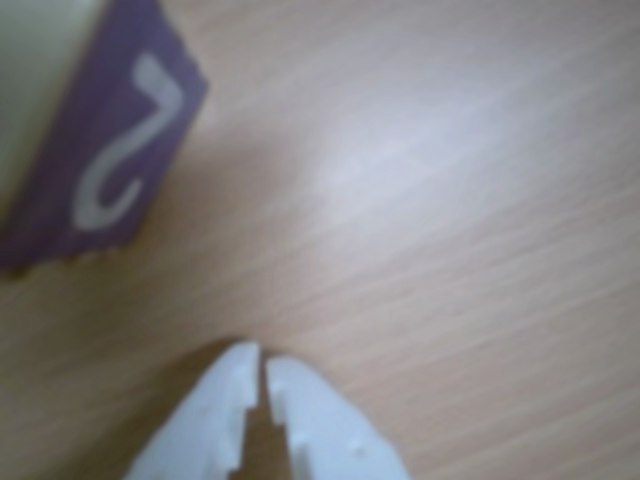

In [56]:
from PIL import Image
from IPython.display import display

import torch

img = dataset[0]['observation.images.wrist']
# Convert tensor to numpy and rearrange axes to (H, W, C)
img_np = img.permute(1, 2, 0).numpy()
img_np = (img_np * 255).astype('uint8')  # Convert to uint8 if needed

# Create PIL image and display
img_pil = Image.fromarray(img_np)

display(img_pil)
